# Modeling2_OLS_interpretation — 감성 보조피처 해석

모델링1 `final_aic_features` 19개를 base로 고정하고, 뉴스 감성 4개를 추가한 모델을
**전체 데이터**로 재적합하여 변수 효과를 해석한다.

순서: **OLS 적합(plain) → 잔차진단(이분산 확인) → HC3 채택 → 계수 해석**

- β 부호·크기, HC3 robust p-value, 표준화 β
- 감성 4개 보조피처 집중 해석 — 계수 유의성, 설명력 변화, 결합 유의성(F-test)
- 변수 그룹별 요약
- 변수 선택은 하지 않는다 (`final_features_v2.json` 확정)


## 1. 설정 + 데이터

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

# 설정 로드 (OLS 예측 노트북이 저장)
CFG_PATH = Path("../outputs/modeling2/final_features_v2.json")
cfg = json.load(open(CFG_PATH, encoding="utf-8"))

TARGET        = cfg["target"]
SPLIT_DATE    = cfg["split_date"]
base_cols     = cfg["base_features"]
sentiment_all = cfg["sentiment_features"]
model_cols    = cfg["all_features"]

print("TARGET     :", TARGET)
print("base       :", len(base_cols), "개")
print("sentiment  :", sentiment_all)
print("전체(+감성):", len(model_cols), "개  (해석은 전체 데이터 기준)")


TARGET     : oil_diff_target
base       : 19 개
sentiment  : ['sent_supply_7d', 'sent_demand_7d', 'sent_geopolitical_7d', 'sent_financial_7d']
전체(+감성): 23 개  (해석은 전체 데이터 기준)


In [2]:
# 데이터 로드 + merge (예측 노트북과 동일)
SENT_PATH = Path("../data/Sentiment_Final/sentiment_avg_7d_final.csv")
BASE_PATH = Path("../data/Finance_Final/dataset4_derived_full_with_dummies.csv")

sent_df = pd.read_csv(SENT_PATH, parse_dates=["date"])
base_df = pd.read_csv(BASE_PATH, parse_dates=["date"])
sent_keep = ["date"] + [c for c in sent_df.columns if c.startswith("sent_")]

df_model = (
    base_df.merge(sent_df[sent_keep], on="date", how="inner")
           .sort_values("date")
           .reset_index(drop=True)
)
df_model = df_model[["date"] + model_cols + [TARGET]].dropna().reset_index(drop=True)

print("해석용 전체 데이터:", df_model.shape)
print("기간:", df_model["date"].min().date(), "~", df_model["date"].max().date())


해석용 전체 데이터: (4547, 25)
기간: 2008-01-31 ~ 2026-03-13


## 2. OLS 적합 (일반 SE)

해석은 표본 밖 일반화가 아니라 변수 효과 파악이 목적이므로 전체 데이터로 적합한다.
먼저 일반 OLS만 적합하고, 표준오차/p-value는 §3 잔차진단 후 §4에서 결정한다.

In [3]:
y_all = df_model[TARGET]
X_base = sm.add_constant(df_model[base_cols],  has_constant="add")
X_sent = sm.add_constant(df_model[model_cols], has_constant="add")

# 일반 OLS만 적합 (robust SE는 §4에서 진단 결과 보고 결정)
ols_base = sm.OLS(y_all, X_base).fit()
ols_sent = sm.OLS(y_all, X_sent).fit()

fit_cmp = pd.DataFrame([
    {"model": "baseline (19)",   "n_vars": len(base_cols),
     "R2": ols_base.rsquared, "Adj_R2": ols_base.rsquared_adj,
     "AIC": ols_base.aic, "BIC": ols_base.bic, "F_pvalue": ols_base.f_pvalue},
    {"model": "+sentiment (23)", "n_vars": len(model_cols),
     "R2": ols_sent.rsquared, "Adj_R2": ols_sent.rsquared_adj,
     "AIC": ols_sent.aic, "BIC": ols_sent.bic, "F_pvalue": ols_sent.f_pvalue},
])
print("===== baseline vs +sentiment 적합도 (일반 OLS) =====")
display(fit_cmp.round(5))


===== baseline vs +sentiment 적합도 (일반 OLS) =====


,model,n_vars,R2,Adj_R2,AIC,BIC,F_pvalue
0,baseline (19),19,0.04024,0.03621,19250.23645,19378.68091,0.0
1,+sentiment (23),23,0.04042,0.03554,19257.40331,19411.53666,0.0


## 3. 잔차진단 — 이분산 / 자기상관 확인

`+sentiment` 모델의 일반 OLS 잔차에 대해 진단한다. (잔차·적합값은 robust SE 적용과 무관하게 동일)
- 자기상관: Durbin-Watson, Ljung-Box, ACF/PACF
- 이분산성: Breusch-Pagan → §4의 HC3 채택 여부 결정

In [4]:
resid = ols_sent.resid
exog  = ols_sent.model.exog

dw = durbin_watson(resid)
lb = acorr_ljungbox(resid, lags=[5, 10, 20], return_df=True)
bp_stat, bp_p, _, _ = het_breuschpagan(resid, exog)

diag = pd.DataFrame({
    "통계": ["Durbin-Watson","Ljung-Box(5)","Ljung-Box(10)","Ljung-Box(20)","Breusch-Pagan"],
    "값":   [dw, float(lb.loc[5,"lb_stat"]), float(lb.loc[10,"lb_stat"]),
             float(lb.loc[20,"lb_stat"]), bp_stat],
    "p-value": [np.nan, float(lb.loc[5,"lb_pvalue"]), float(lb.loc[10,"lb_pvalue"]),
                float(lb.loc[20,"lb_pvalue"]), bp_p],
})
display(diag.round(6))

lb10_p = float(lb.loc[10, "lb_pvalue"])
print("[자동 판정]")
print("  자기상관:", "있음 (Ljung-Box lag10 p<0.05)" if lb10_p < 0.05 else "없음")
print("  이분산  :", "있음 (Breusch-Pagan p<0.05)" if bp_p < 0.05 else "없음")
print(f"  Durbin-Watson = {dw:.4f}")


,통계,값,p-value
0,Durbin-Watson,1.996719,NaN
1,Ljung-Box(5),4.810027,0.439502
2,Ljung-Box(10),7.087545,0.717155
3,Ljung-Box(20),26.216163,0.158791
4,Breusch-Pagan,209.812547,0.000000


[자동 판정]
  자기상관: 없음
  이분산  : 있음 (Breusch-Pagan p<0.05)
  Durbin-Watson = 1.9967


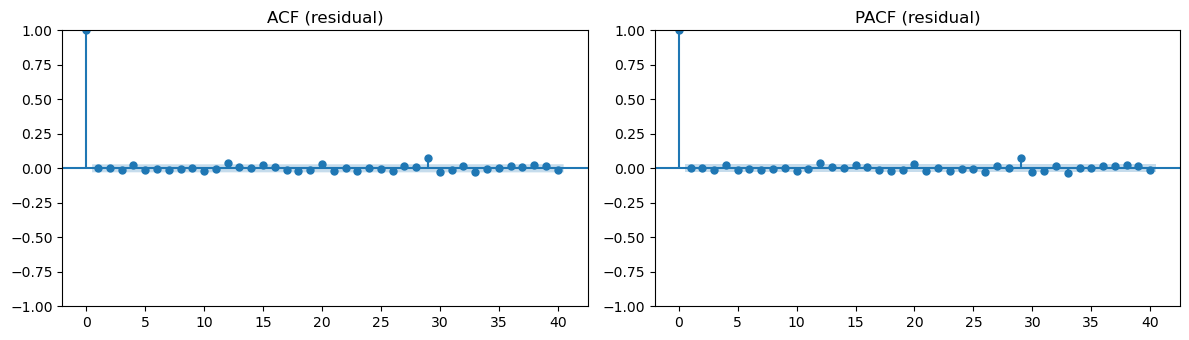

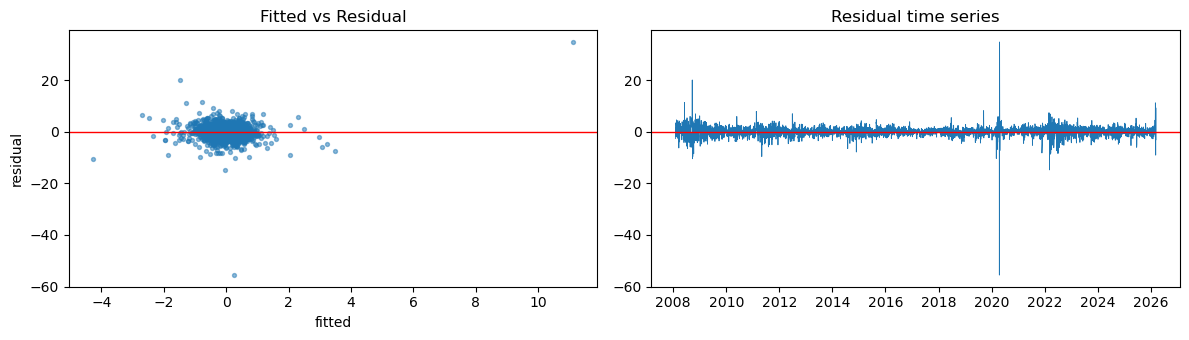

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(resid,  lags=40, ax=axes[0]); axes[0].set_title("ACF (residual)")
plot_pacf(resid, lags=40, ax=axes[1], method="ywm"); axes[1].set_title("PACF (residual)")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].scatter(ols_sent.fittedvalues, resid, s=8, alpha=0.5)
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("fitted"); axes[0].set_ylabel("residual"); axes[0].set_title("Fitted vs Residual")
axes[1].plot(df_model["date"], resid, lw=0.6)
axes[1].axhline(0, color="red", lw=1); axes[1].set_title("Residual time series")
plt.tight_layout(); plt.show()


## 4. robust SE 채택

§3 진단 결과에 따라 표준오차를 결정한다.
- Breusch-Pagan p < 0.05 (이분산) → **HC3 robust SE 채택**
- Ljung-Box p < 0.05 (자기상관까지) → HAC(Newey-West) 추가 고려 권장

In [6]:
use_hc3 = bp_p < 0.05
use_hac = lb10_p < 0.05

print(f"Breusch-Pagan p = {bp_p:.5f}  -> 이분산 {'있음' if use_hc3 else '없음'}")
print(f"Ljung-Box(10) p = {lb10_p:.5f}  -> 자기상관 {'있음' if use_hac else '없음'}")

if use_hc3:
    print("\n-> 이분산 존재. HC3 robust SE를 채택하여 계수 유의성을 판단한다.")
else:
    print("\n-> 이분산 없음. 일반 SE로 충분하나, 비교 목적으로 HC3도 함께 적합한다.")
if use_hac:
    print("   자기상관도 존재하므로 보고 시 HAC(Newey-West) 보강을 고려한다.")

# robust SE 적용 모델 (점추정은 §2와 동일, SE/p-value만 보정)
ols_sent_hc3 = sm.OLS(y_all, X_sent).fit(cov_type="HC3")
print("\nHC3 robust SE 모델 적합 완료 (이하 계수 해석은 HC3 기준)")


Breusch-Pagan p = 0.00000  -> 이분산 있음
Ljung-Box(10) p = 0.71716  -> 자기상관 없음

-> 이분산 존재. HC3 robust SE를 채택하여 계수 유의성을 판단한다.

HC3 robust SE 모델 적합 완료 (이하 계수 해석은 HC3 기준)


## 5. +sentiment 모델 계수 표 (HC3 robust SE)

In [7]:
def sig_stars(p):
    if pd.isna(p): return ""
    if p < 0.01:   return "***"
    if p < 0.05:   return "**"
    if p < 0.10:   return "*"
    return ""

rows = []
for v in model_cols:
    coef = ols_sent_hc3.params[v]
    rows.append({
        "variable":  v,
        "is_sentiment": v in sentiment_all,
        "coef":      coef,
        "SE_HC3":    ols_sent_hc3.bse[v],
        "t_HC3":     ols_sent_hc3.tvalues[v],
        "p_HC3":     ols_sent_hc3.pvalues[v],
        "sig":       sig_stars(ols_sent_hc3.pvalues[v]),
        "std_beta":  coef * df_model[v].std(),
    })
coef_df = pd.DataFrame(rows)
coef_df["abs_std_beta"] = coef_df["std_beta"].abs()

print("===== 계수 표 (p_HC3 오름차순) =====")
display(coef_df.sort_values("p_HC3").round(6).reset_index(drop=True))


===== 계수 표 (p_HC3 오름차순) =====


,variable,is_sentiment,coef,SE_HC3,t_HC3,p_HC3,sig,std_beta,abs_std_beta
0,opec_2014_window,False,-1.000522,0.470721,-2.125509,0.033544,**,-0.064548,0.064548
1,oil_diff_lag1,False,-0.068710,0.034855,-1.971327,0.048686,**,-0.140210,0.140210
2,cond_opec_cut,False,-0.169076,0.090569,-1.866827,0.061926,*,-0.072988,0.072988
3,CPE,False,-0.001398,0.000768,-1.821013,0.068605,*,-0.219691,0.219691
4,OPECProduction,False,-0.000186,0.000108,-1.724265,0.084660,*,-0.112274,0.112274
5,RealInterestRate,False,-0.295962,0.174841,-1.692750,0.090503,*,-0.060122,0.060122
6,gfc_2008_regime,False,0.500005,0.307929,1.623764,0.104426,,0.081445,0.081445
7,MA_5_gt_MA_20,False,0.346961,0.232811,1.490313,0.136142,,0.172933,0.172933
8,MA_ratio,False,-4.874009,3.345266,-1.456987,0.145120,,-0.286852,0.286852
9,IndustryProduction,False,0.082364,0.060524,1.360852,0.173560,,0.103695,0.103695


## 6. 감성 보조피처 집중 해석

감성 4개가 (1) 개별적으로 유의한지, (2) 결합해서 유의한지(F-test), (3) 설명력을 얼마나 더하는지 본다.

In [8]:
# 6-1. 감성 변수만 계수 표
sent_coef = coef_df[coef_df["is_sentiment"]].copy()
print("===== 감성 보조피처 계수 (HC3) =====")
display(sent_coef[["variable","coef","SE_HC3","p_HC3","sig","std_beta"]].round(6).reset_index(drop=True))

# 6-2. baseline 대비 설명력 변화
print("\n[설명력 변화] baseline -> +sentiment")
print(f"  R2     : {ols_base.rsquared:.5f} -> {ols_sent.rsquared:.5f}  ({ols_sent.rsquared-ols_base.rsquared:+.5f})")
print(f"  Adj_R2 : {ols_base.rsquared_adj:.5f} -> {ols_sent.rsquared_adj:.5f}  ({ols_sent.rsquared_adj-ols_base.rsquared_adj:+.5f})")
print(f"  AIC    : {ols_base.aic:.2f} -> {ols_sent.aic:.2f}  ({ols_sent.aic-ols_base.aic:+.2f})")

# 6-3. 감성 4개 결합 유의성 (nested F-test: 감성 계수 전부 0 인가)
f_stat, f_p, df_diff = ols_sent.compare_f_test(ols_base)
print(f"\n[F-test] H0: 감성 4개 계수 모두 0")
print(f"  F = {f_stat:.4f}, p-value = {f_p:.5f}, df_diff = {df_diff:.0f}")
print(f"  -> {'기각: 감성 변수 결합 유의' if f_p < 0.05 else '기각 못함: 감성 변수 결합 효과 없음'}")


===== 감성 보조피처 계수 (HC3) =====


,variable,coef,SE_HC3,p_HC3,sig,std_beta
0,sent_supply_7d,-0.015392,0.078436,0.844428,,-0.005868
1,sent_demand_7d,0.004729,0.069397,0.945668,,0.001878
2,sent_geopolitical_7d,-0.013848,0.142810,0.922752,,-0.003461
3,sent_financial_7d,0.083243,0.091506,0.362982,,0.030674



[설명력 변화] baseline -> +sentiment
  R2     : 0.04024 -> 0.04042  (+0.00018)
  Adj_R2 : 0.03621 -> 0.03554  (-0.00068)
  AIC    : 19250.24 -> 19257.40  (+7.17)

[F-test] H0: 감성 4개 계수 모두 0
  F = 0.2072, p-value = 0.93453, df_diff = 4
  -> 기각 못함: 감성 변수 결합 효과 없음


## 7. 변수 그룹별 해석

In [9]:
MACRO_SET  = {"VIX","DollarIndex","RealInterestRate","CPI","TreasuryYield","FedFundsRate"}
DUMMY_EXACT = {"is_monday","is_friday","vix_high"}

def classify(v):
    if v in sentiment_all:
        return "감성(보조)"
    if v.startswith("MA_") or v.startswith("oil_momentum_") or v.startswith("oil_diff_lag"):
        return "가격/추세"
    if v.startswith("oil_volatility_"):
        return "변동성"
    if v in MACRO_SET or v.startswith("TermSpread_"):
        return "거시"
    if v in DUMMY_EXACT or v.endswith("_shock") or v.endswith("_regime") or v.endswith("_window") or v.startswith("cond_") or v.startswith("gfc_"):
        return "더미/이벤트"
    return "기타"

coef_df["group"] = coef_df["variable"].map(classify)

group_df = (coef_df.groupby("group")
            .apply(lambda g: pd.Series({
                "n_vars": len(g),
                "n_sig_0.05": int((g["p_HC3"] < 0.05).sum()),
                "mean_abs_std_beta": g["abs_std_beta"].mean(),
                "n_positive": int((g["coef"] > 0).sum()),
                "n_negative": int((g["coef"] < 0).sum()),
            }))
            .reset_index()
            .sort_values("mean_abs_std_beta", ascending=False))

print("===== 그룹별 효과 요약 =====")
display(group_df.round(6).reset_index(drop=True))


===== 그룹별 효과 요약 =====


,group,n_vars,n_sig_0.05,mean_abs_std_beta,n_positive,n_negative
0,가격/추세,3.0,1.0,0.199998,1.0,2.0
1,기타,5.0,0.0,0.155426,1.0,4.0
2,더미/이벤트,8.0,1.0,0.080021,2.0,6.0
3,거시,3.0,0.0,0.062044,1.0,2.0
4,감성(보조),4.0,0.0,0.010470,2.0,2.0


## 8. 저장

In [10]:
OUT_DIR = Path("../outputs/modeling2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_coef = coef_df[["variable","group","is_sentiment","coef","SE_HC3","p_HC3","sig","std_beta"]]
out_coef.to_csv(OUT_DIR / "ols2_interpretation_coefficients.csv", index=False, encoding="utf-8-sig")
group_df.to_csv(OUT_DIR / "ols2_interpretation_groups.csv", index=False, encoding="utf-8-sig")

print("저장 완료:")
print(" -", OUT_DIR / "ols2_interpretation_coefficients.csv")
print(" -", OUT_DIR / "ols2_interpretation_groups.csv")


저장 완료:
 - ../outputs/modeling2/ols2_interpretation_coefficients.csv
 - ../outputs/modeling2/ols2_interpretation_groups.csv
